<a href="https://colab.research.google.com/github/Meowmixforme/Squirrel-Red/blob/main/Squirrel_Red_Sampling_BIAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Urban vs Forest Cover.

##### Urban:
##### We can see areas are either highly urban or highly rural. Forest cover varies widely in both areas.
##### Most sightings occour in areas with high forest cover.
##### Rural areas have many sightings but also lower counts.
##### Urban areas show a wide variation with some very high counts - likely from gardens.
##### More sightings in Medium and High forest cover areas
##### Very Low forest cover areas have fewer sightings
##### Highest individual counts appear in Medium/High forest categories

##### Correlation Matrix:
##### Weak positive correlation (0.27) between urban percentage and sighting count
##### Weak positive correlation (0.20) between forest cover and sighting count
##### Almost no correlation (-0.0052) between urban percentage and forest cover

##### Key Insights:
##### Squirrels are found in both urban and rural environments
##### Higher forest cover generally supports more squirrel sightings
##### Urban areas can have very high concentrations of sightings
##### Scotland shows a distinct urban/rural divide with few intermediate areas

Connecting to MongoDB

Forest and Urban Coverage Analysis:
--------------------------------------------------

Correlation Matrix:
                  sighting_count  urban_percentage     cover
sighting_count          1.000000          0.273089  0.195803
urban_percentage        0.273089          1.000000 -0.005162
cover                   0.195803         -0.005162  1.000000

Mean Sightings by Forest and Urban Categories:
urban_category       Rural  High Urban
forest_category                       
Very Low          2.181452    6.038462
Low              29.580460  141.246154
Medium           77.068027  281.910714
High             99.662037  259.068182

Detailed Urban Coverage Distribution:
(-0.101, 10.0]    785
(10.0, 20.0]        0
(20.0, 30.0]        0
(30.0, 40.0]        0
(40.0, 50.0]        0
(50.0, 60.0]        0
(60.0, 70.0]        0
(70.0, 80.0]        0
(80.0, 90.0]        0
(90.0, 100.0]     191
Name: count, dtype: int64

Sightings by Urban Category:
                count       

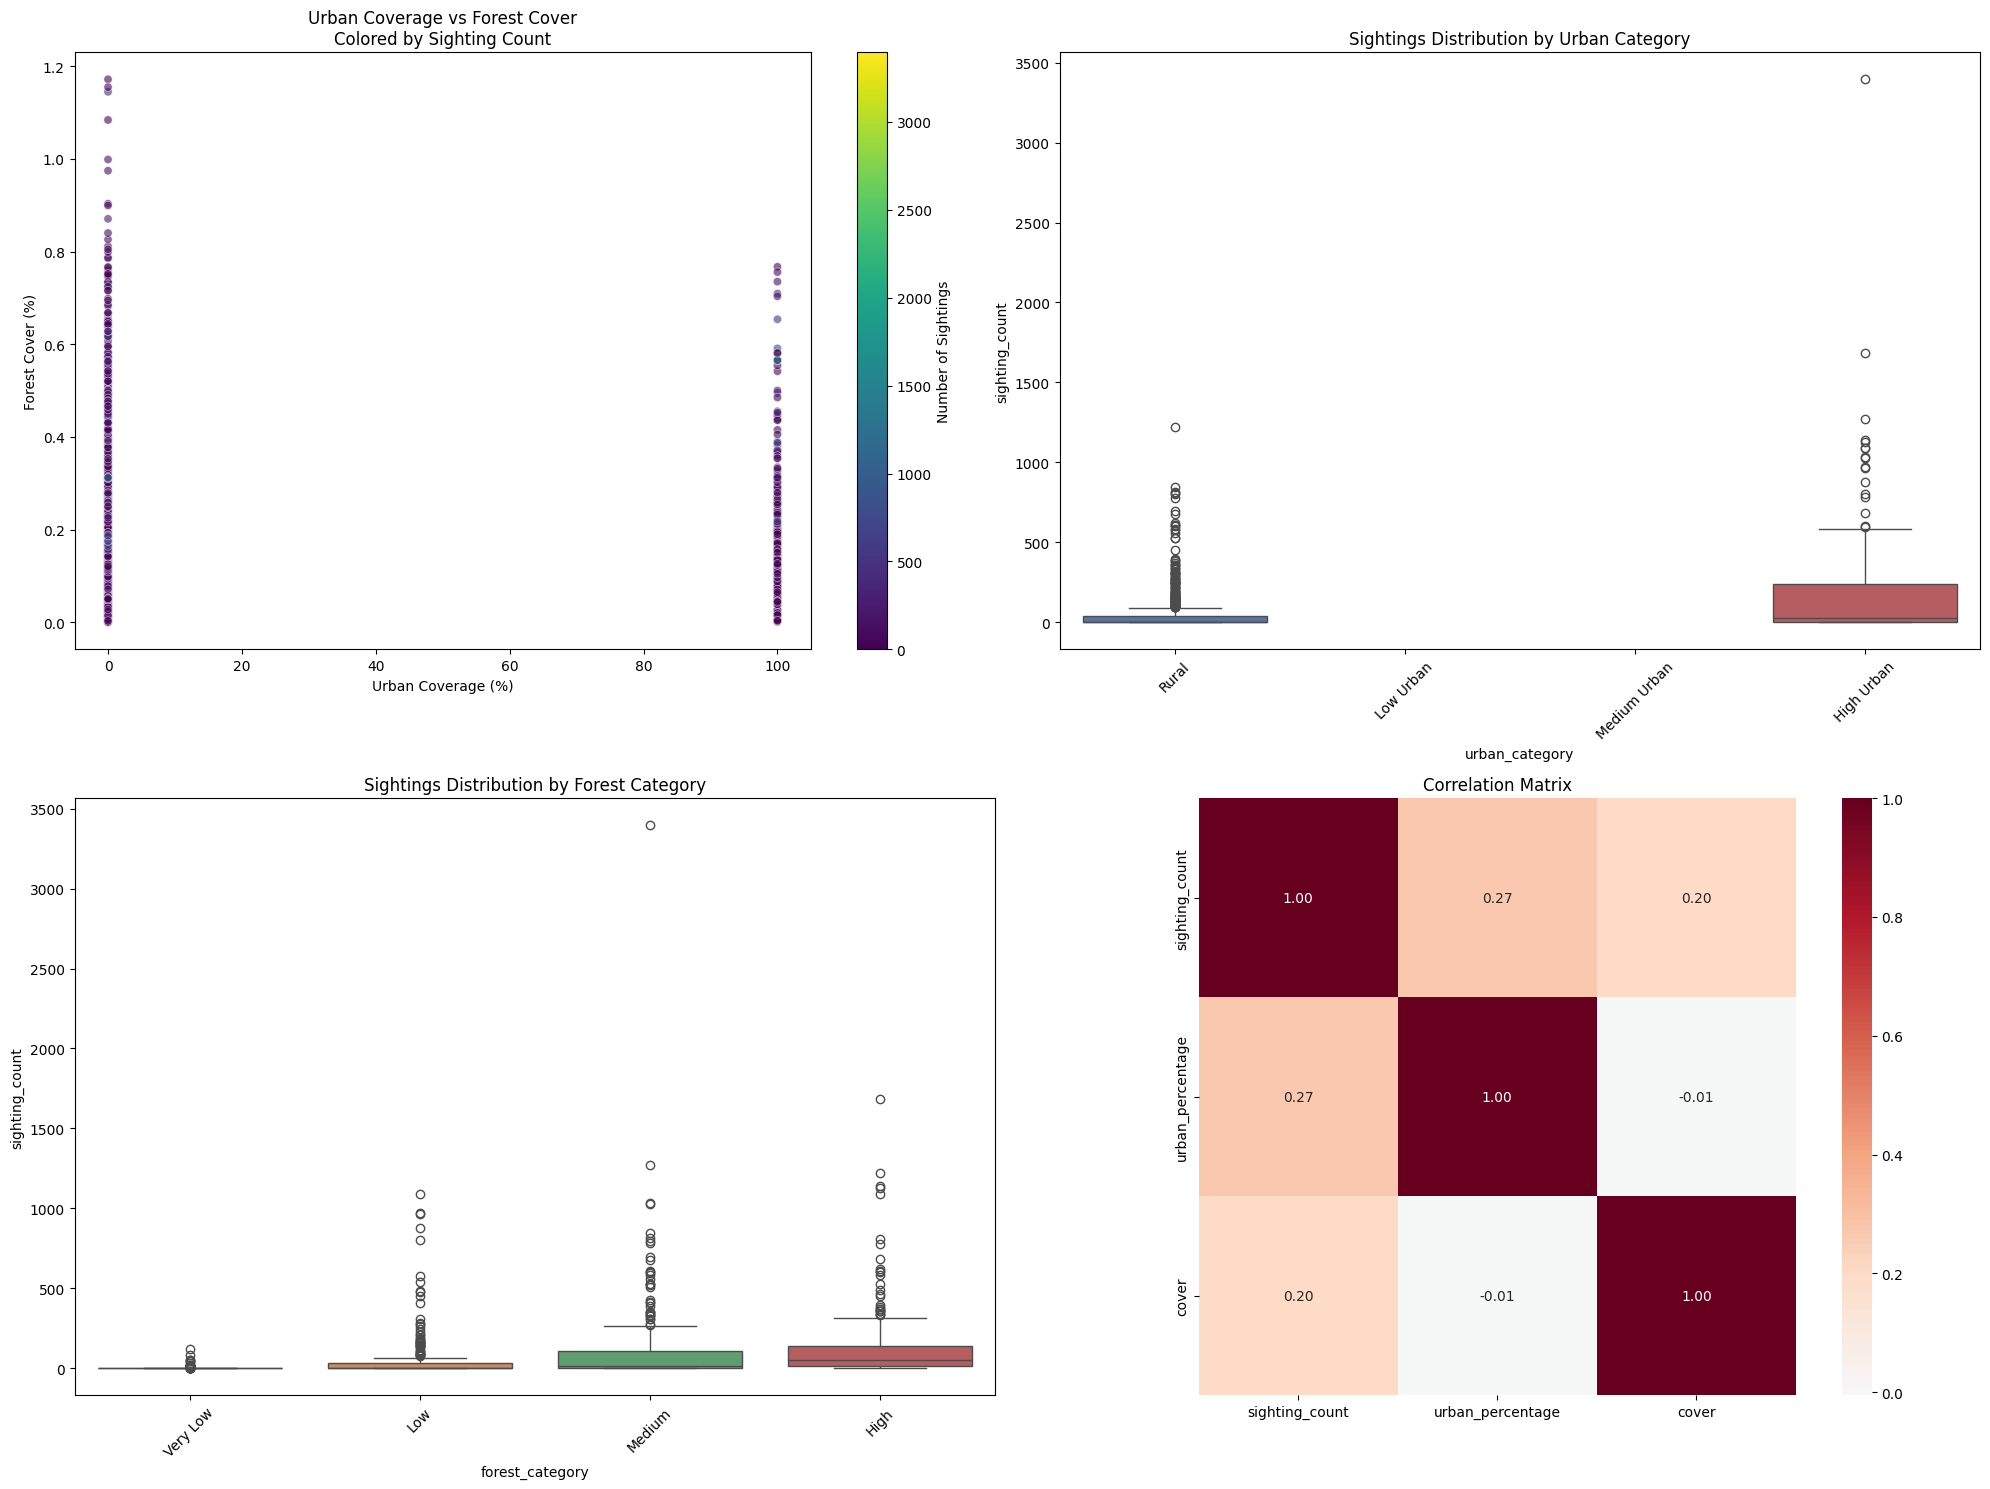

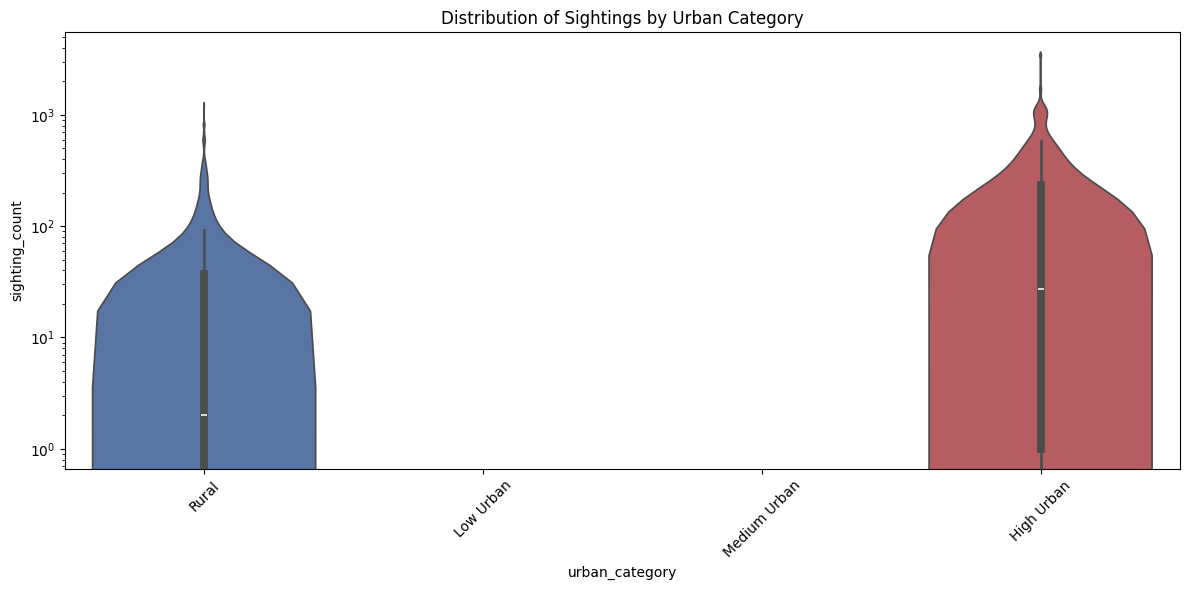


Summary Statistics:

Forest Cover Distribution:
count    976.000000
mean       0.209194
std        0.214310
min        0.000052
25%        0.039591
50%        0.135884
75%        0.313883
max        1.171946
Name: cover, dtype: float64

Urban Coverage Distribution:
count    976.000000
mean      19.569671
std       39.693945
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      100.000000
Name: urban_percentage, dtype: float64

Squirrel Sightings Distribution:
count     976.000000
mean       76.913934
std       206.580032
min         0.000000
25%         0.000000
50%         3.000000
75%        55.000000
max      3396.000000
Name: sighting_count, dtype: float64

Number of grid squares in each category:

Forest Categories:
forest_category
Very Low    274
High        260
Low         239
Medium      203
Name: count, dtype: int64

Urban Categories:
urban_category
Rural           785
High Urban      191
Low Urban         0
Medium Urban      0
Name: count, 

In [ ]:
# Install packages
!pip install pymongo folium dnspython libpysal esda splot seaborn

# Imports
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from shapely.geometry import shape, Point
import folium
from folium import plugins
import warnings
warnings.filterwarnings('ignore')

# Connect to MongoDB
connection_string = os.getenv("MONGODB_URI")
if not connection_string:
    raise ValueError("MongoDB URI not found. Check your .env file.")

client = MongoClient(connection_string)

# Load and convert data to British National Grid

# Forest cover data
forest_collection = client['Scottish_Forest_Cover']['Forest Cover Scotland']
forest_data = list(forest_collection.find())
forest_gdf = gpd.GeoDataFrame.from_features(forest_data)
forest_gdf.set_crs(epsg=4326, inplace=True)
forest_gdf = forest_gdf.to_crs(epsg=27700)

# Urban data
urban_collection = client['Urban']['Scottish Urban Coverage']
urban_data = list(urban_collection.find())
urban_gdf = gpd.GeoDataFrame.from_features(urban_data)
urban_gdf.set_crs(epsg=4326, inplace=True)
urban_gdf = urban_gdf.to_crs(epsg=27700)

# Squirrel data
squirrel_collection = client['Squirrel_Spatial']["squirrel_data_2010_2022"]
squirrel_docs = list(squirrel_collection.find())
squirrel_features = []
for doc in squirrel_docs:
    if 'geometry' in doc and 'coordinates' in doc['geometry']:
        feature = {
            'type': 'Feature',
            'geometry': doc['geometry'],
            'properties': doc.get('properties', {})
        }
        squirrel_features.append(feature)

squirrel_gdf = gpd.GeoDataFrame.from_features(squirrel_features)
squirrel_gdf.set_crs(epsg=4326, inplace=True)
squirrel_gdf = squirrel_gdf.to_crs(epsg=27700)

# Calculate metrics for each forest grid
for idx, grid_cell in forest_gdf.iterrows():
    # Count squirrel sightings
    points_in_cell = squirrel_gdf[squirrel_gdf.within(grid_cell.geometry)]
    forest_gdf.at[idx, 'sighting_count'] = len(points_in_cell)

    # Calculate urban coverage
    urban_intersect = urban_gdf[urban_gdf.intersects(grid_cell.geometry)]
    if len(urban_intersect) > 0:
        urban_area = urban_intersect.geometry.area.sum()
        cell_area = grid_cell.geometry.area
        forest_gdf.at[idx, 'urban_percentage'] = (urban_area / cell_area) * 100
    else:
        forest_gdf.at[idx, 'urban_percentage'] = 0

# Normalise urban percentage if over 100%
forest_gdf['urban_percentage'] = forest_gdf['urban_percentage'].clip(upper=100)

# Create categories for forest cover and urban percentage
forest_gdf['forest_category'] = pd.cut(forest_gdf['cover'],
                                     bins=[0, 0.05, 0.15, 0.30, 1.2],
                                     labels=['Very Low', 'Low', 'Medium', 'High'])

forest_gdf['urban_category'] = pd.cut(forest_gdf['urban_percentage'],
                                    bins=[-np.inf, 0, 20, 50, 100],
                                    labels=['Rural', 'Low Urban', 'Medium Urban', 'High Urban'])

# Add sighting density
forest_gdf['sighting_density'] = forest_gdf['sighting_count'] / forest_gdf.geometry.area

# Convert back to WGS84 for mapping
forest_gdf_wgs84 = forest_gdf.to_crs(epsg=4326)
urban_gdf_wgs84 = urban_gdf.to_crs(epsg=4326)
squirrel_gdf_wgs84 = squirrel_gdf.to_crs(epsg=4326)

# Statistical analysis
print("\nForest and Urban Coverage Analysis:")
print("-" * 50)

# Calculate correlations
corr = forest_gdf[['sighting_count', 'urban_percentage', 'cover']].corr()
print("\nCorrelation Matrix:")
print(corr)

# Average number of squirrel sightings for each combination of forest cover and urban categories
print("\nMean Sightings by Forest and Urban Categories:")
cross_tab = pd.pivot_table(forest_gdf,
                          values='sighting_count',
                          index='forest_category',
                          columns='urban_category',
                          aggfunc='mean')
print(cross_tab)

# Print urban percentage distribution details
print("\nDetailed Urban Coverage Distribution:")
print(forest_gdf['urban_percentage'].value_counts(bins=10).sort_index())

# Calculate mean sightings for each urban percentage range
urban_sightings = forest_gdf.groupby('urban_category')['sighting_count'].agg(['count', 'mean', 'median', 'max'])
print("\nSightings by Urban Category:")
print(urban_sightings)

# Print sighting density by urban category
print("\nSighting Density by Urban Category:")
print(forest_gdf.groupby('urban_category')['sighting_density'].mean())

# Create figure with subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 15))

# Scatter plot
scatter = sns.scatterplot(data=forest_gdf,
                         x='urban_percentage',
                         y='cover',
                         hue='sighting_count',
                         palette='viridis',
                         alpha=0.6,
                         legend=False,
                         ax=ax1)
norm = plt.Normalize(forest_gdf['sighting_count'].min(), forest_gdf['sighting_count'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
plt.colorbar(sm, ax=ax1, label='Number of Sightings')
ax1.set_title('Urban Coverage vs Forest Cover\nColored by Sighting Count')
ax1.set_xlabel('Urban Coverage (%)')
ax1.set_ylabel('Forest Cover (%)')

# Box plot of sightings by urban category
sns.boxplot(data=forest_gdf,
            x='urban_category',
            y='sighting_count',
            palette='deep',
            ax=ax2)
ax2.set_title('Sightings Distribution by Urban Category')
ax2.tick_params(axis='x', rotation=45)

# Box plot of sightings by forest category
sns.boxplot(data=forest_gdf,
            x='forest_category',
            y='sighting_count',
            palette='deep',
            ax=ax3)
ax3.set_title('Sightings Distribution by Forest Category')
ax3.tick_params(axis='x', rotation=45)

# Correlation heatmap
sns.heatmap(corr,
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            square=True,
            ax=ax4)
ax4.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

# Violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=forest_gdf,
               x='urban_category',
               y='sighting_count',
               palette='deep')
plt.yscale('log')  # Use log scale due to large range
plt.title('Distribution of Sightings by Urban Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Interactive map
m = folium.Map(location=[57.0, -4.0], zoom_start=7)

# Urban areas
folium.GeoJson(
    urban_gdf_wgs84,
    name='Urban Areas',
    style_function=lambda x: {
        'fillColor': 'gray',
        'fillOpacity': 0.3,
        'color': 'gray',
        'weight': 1
    }
).add_to(m)

# Forest grid squares
def style_function(feature):
    forest_cover = feature['properties'].get('cover', 0)
    urban_pct = feature['properties'].get('urban_percentage', 0)
    sightings = feature['properties'].get('sighting_count', 0)

    return {
        'fillColor': '#28a745' if forest_cover > 0 else 'none',
        'fillOpacity': min(forest_cover/100, 0.8) if forest_cover > 0 else 0.1,
        'color': 'red' if sightings > 0 else 'black',
        'weight': 2 if sightings > 0 else 1
    }

folium.GeoJson(
    forest_gdf_wgs84.__geo_interface__,
    name='Forest Grids',
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['TILE_NAME', 'cover', 'urban_percentage', 'sighting_count'],
        aliases=['Grid Reference', 'Forest Cover (%)', 'Urban Coverage (%)', 'Squirrel Sightings'],
        localize=True
    )
).add_to(m)

# Squirrel sightings heatmap
heat_data = [[point.y, point.x] for point in squirrel_gdf_wgs84.geometry]
plugins.HeatMap(
    heat_data,
    name='Squirrel Sightings',
    min_opacity=0.3,
    radius=15,
    blur=10,
    max_zoom=1,
).add_to(m)

# Layer control
folium.LayerControl().add_to(m)

# Save map
m.save('forest_urban_squirrel.html')

# Statistics
print("\nSummary Statistics:")
print("\nForest Cover Distribution:")
print(forest_gdf['cover'].describe())

print("\nUrban Coverage Distribution:")
print(forest_gdf['urban_percentage'].describe())

print("\nSquirrel Sightings Distribution:")
print(forest_gdf['sighting_count'].describe())

print("\nNumber of grid squares in each category:")
print("\nForest Categories:")
print(forest_gdf['forest_category'].value_counts())
print("\nUrban Categories:")
print(forest_gdf['urban_category'].value_counts())

client.close()
print("\nMongoDB connection closed")

##### Analyse duplicate reporting within a time window

##### The function finds points at exactly the same location (within 0.1m) on the same day and keeps one while marking the other as a duplicate.
##### It then finds points that are nearby one another (50m) on the same day and uses coordinate uncertainty to see if they're duplicates (if distance is less than coordinate uncertainty they are a duplicate).

In [ ]:
# Install Packages
!pip install pymongo folium dnspython pytz

import pandas as pd
import geopandas as gpd
import numpy as np
from pymongo import MongoClient
from datetime import datetime, timedelta
import pytz
from shapely.geometry import Point

# Connect to MongoDB
connection_string = os.getenv("MONGODB_URI")
if not connection_string:
    raise ValueError("MongoDB URI not found. Check your .env file.")

client = MongoClient(connection_string)

# Load squirrel data with timestamps
squirrel_collection = client['Squirrel_Spatial']["squirrel_data_2010_2022"]
squirrel_docs = list(squirrel_collection.find())
records = []

for doc in squirrel_docs:
    if 'geometry' in doc and 'coordinates' in doc['geometry']:
        try:
            # Get coordinates from geometry
            coords = doc['geometry']['coordinates']

            # Get date from properties
            date_str = doc['properties'].get('Date')
            if date_str:
                dt = datetime.strptime(date_str, '%Y-%m-%d')
                dt = pytz.UTC.localize(dt)

                record = {
                    'datetime': dt,
                    'latitude': coords[1],
                    'longitude': coords[0],
                    'season': doc['properties'].get('season'),
                    'occurrence_id': doc['properties'].get('Occurrence_ID'),
                    'coordinate_uncertainty': doc['properties'].get('Coordinate_uncertainty')
                }
                records.append(record)
        except Exception as e:
            print(f"Error processing record: {e}")
            continue

# Create DataFrame
df = pd.DataFrame(records)

print(f"\nTotal records processed: {len(df)}")
print("\nDataFrame structure:")
print(df.info())

# Create geometry column
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]

# Create GeoDataFrame
squirrel_gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Convert to British National Grid for accurate distances
squirrel_gdf = squirrel_gdf.to_crs(epsg=27700)


    # Find groups of squirrel sightings that are likely duplicates based on:
    # Time - sightings within the same 30-minute window
    # Distance - sightings within 100 meters of each other
def find_duplicate_groups(gdf, time_window_minutes=30, distance_threshold_meters=100):
    # Sort by datetime
    gdf = gdf.sort_values('datetime')

    duplicate_groups = []
    used_indices = set()

    total_records = len(gdf)
    print(f"\nProcessing {total_records} records")

    for idx, row in gdf.iterrows():
        if idx in used_indices:
            continue

        # Get current point's location and time
        current_point = row.geometry
        current_time = row.datetime

        # Find all points within time window and distance threshold
        time_mask = (gdf['datetime'] == current_time)  # Same day
        points_in_window = gdf[time_mask]

        # Calculate distances to current point
        distances = points_in_window.geometry.distance(current_point)
        nearby_points = points_in_window[distances <= distance_threshold_meters]

        if len(nearby_points) > 1:  # If there are multiple sightings
            duplicate_groups.append({
                'datetime': current_time,
                'num_sightings': len(nearby_points),
                'max_distance': distances[distances <= distance_threshold_meters].max(),
                'occurrence_ids': nearby_points['occurrence_id'].tolist(),
                'coordinate_uncertainties': nearby_points['coordinate_uncertainty'].tolist()
            })

            used_indices.update(nearby_points.index)

        # Print progress every 1000 records
        if idx % 1000 == 0:
            print(f"Processed {idx}/{total_records} records")

    return duplicate_groups

# Find duplicate groups
print("\nFinding duplicate groups")
duplicate_groups = find_duplicate_groups(squirrel_gdf, distance_threshold_meters=100)

# Analyse results
if duplicate_groups:
    num_duplicates = len(duplicate_groups)
    total_duplicate_sightings = sum(group['num_sightings'] for group in duplicate_groups)
    avg_group_size = total_duplicate_sightings / num_duplicates
    avg_distance = np.mean([group['max_distance'] for group in duplicate_groups])

    print("\nDuplicate Sighting Analysis:")
    print("-" * 50)
    print(f"Number of potential duplicate groups: {num_duplicates}")
    print(f"Total sightings in duplicate groups: {total_duplicate_sightings}")
    print(f"Average sightings per group: {avg_group_size:.2f}")
    print(f"Average maximum distance within groups: {avg_distance:.2f} meters")

    # Print example duplicate groups
    print("\nExample Duplicate Groups:")
    print("-" * 50)
    for i, group in enumerate(duplicate_groups[:5]):  # Show first 5 groups
        print(f"\nGroup {i+1}:")
        print(f"Date: {group['datetime'].date()}")
        print(f"Number of sightings: {group['num_sightings']}")
        print(f"Maximum distance between sightings: {group['max_distance']:.2f} meters")
        print(f"Occurrence IDs: {group['occurrence_ids']}")
        print(f"Coordinate uncertainties: {group['coordinate_uncertainties']}")

    # Calculate percentage of duplicate sightings
    total_sightings = len(squirrel_gdf)
    duplicate_sightings = total_duplicate_sightings - num_duplicates
    duplicate_percentage = (duplicate_sightings / total_sightings) * 100

    print(f"\nOverall Statistics:")
    print(f"Total number of sightings: {total_sightings}")
    print(f"Number of potential duplicate sightings: {duplicate_sightings}")
    print(f"Percentage of sightings that are potential duplicates: {duplicate_percentage:.2f}%")

else:
    print("\nNo duplicate groups found")

# Analyse seasonal patterns
if 'season' in squirrel_gdf.columns:
    print("\nSeasonal Analysis of Duplicates:")
    print("-" * 50)
    seasonal_groups = {}
    for group in duplicate_groups:
        season = squirrel_gdf.loc[squirrel_gdf['occurrence_id'].isin(group['occurrence_ids']), 'season'].iloc[0]
        seasonal_groups[season] = seasonal_groups.get(season, 0) + 1

    for season, count in seasonal_groups.items():
        print(f"{season}: {count} duplicate groups")

client.close()
print("\nMongoDB connection closed")

Connecting to MongoDB

Total records processed: 75068

DataFrame structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75068 entries, 0 to 75067
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   datetime                75068 non-null  datetime64[ns, UTC]
 1   latitude                75068 non-null  float64            
 2   longitude               75068 non-null  float64            
 3   season                  75068 non-null  object             
 4   occurrence_id           75068 non-null  object             
 5   coordinate_uncertainty  75068 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(3), object(2)
memory usage: 3.4+ MB
None

Finding duplicate groups

Processing 75068 records
Processed 1000/75068 records
Processed 36000/75068 records
Processed 3000/75068 records
Processed 34000/75068 records
Processed 42000/75068 records
Processed 64000

##### Remove duplicates function

##### The function finds points at exactly the same location (within 0.1m) on the same day and keeps one while marking the other as a duplicate.

##### It then finds points that are nearby one another (50m) on the same day and uses coordinate uncertainty to see if they're duplicates (if distance is less than coordinate uncertainty they are a duplicate).


In [ ]:
# Install packages
!pip install pymongo folium dnspython pytz

# Imports
import pandas as pd
import geopandas as gpd
import numpy as np
from pymongo import MongoClient
from datetime import datetime, timedelta
import pytz
from shapely.geometry import Point

# Connect to MongoDB
connection_string = os.getenv("MONGODB_URI")
if not connection_string:
    raise ValueError("MongoDB URI not found. Check your .env file.")

client = MongoClient(connection_string)

# Load squirrel data with ALL properties
squirrel_collection = client['Squirrel_Spatial']["squirrel_data_2010_2022"]
squirrel_docs = list(squirrel_collection.find())
records = []

for doc in squirrel_docs:
    if 'geometry' in doc and 'coordinates' in doc['geometry']:
        try:
            # Get coordinates from geometry
            coords = doc['geometry']['coordinates']

            # Convert to Point geometry
            point = Point(coords)

            # Create record with ALL original properties
            record = doc.copy()  # Copy all original data
            record['geometry'] = point  # Replace geometry with Point object
            records.append(record)

        except Exception as e:
            print(f"Error processing record: {e}")
            continue

# Create GeoDataFrame with all properties
squirrel_gdf = gpd.GeoDataFrame(records)
squirrel_gdf.set_geometry('geometry', inplace=True)
squirrel_gdf.set_crs(epsg=4326, inplace=True)
squirrel_gdf = squirrel_gdf.to_crs(epsg=27700)

def filter_duplicates(squirrel_gdf, distance_threshold=50, coordinate_tolerance=0.1):
    """
    Filter duplicate squirrel sightings using refined criteria
    """
    # Sort by datetime
    gdf = squirrel_gdf.copy()

    # Convert date strings to datetime objects
    gdf['datetime'] = pd.to_datetime(gdf['properties'].apply(lambda x: x.get('Date')))
    gdf = gdf.sort_values('datetime')

    duplicate_indices = set()
    unique_indices = set()

    for idx, row in gdf.iterrows():
        if idx in duplicate_indices:
            continue

        # Get current point's location and time
        current_point = row.geometry
        current_time = row['datetime']

        # Find all points on the same day
        time_mask = (gdf['datetime'] == current_time)
        points_in_window = gdf[time_mask]

        # Calculate distances to current point
        distances = points_in_window.geometry.distance(current_point)

        # Identify duplicates using different criteria
        exact_matches = distances <= coordinate_tolerance  # Almost exact same location
        nearby_matches = (distances <= distance_threshold) & (distances > coordinate_tolerance)

        if exact_matches.sum() > 1:
            # Keep only one of the exact matches
            duplicate_indices.update(points_in_window[exact_matches].index[1:])
            unique_indices.add(points_in_window[exact_matches].index[0])

        if nearby_matches.sum() > 0:
            # For nearby matches, consider coordinate uncertainty
            nearby_points = points_in_window[nearby_matches]
            uncertainties = nearby_points['properties'].apply(lambda x: x.get('Coordinate_uncertainty', 70.7))

            # If distance is less than combined uncertainty, likely duplicate
            for near_idx, uncertainty in zip(nearby_points.index, uncertainties):
                current_uncertainty = row['properties'].get('Coordinate_uncertainty', 70.7)
                if distances[near_idx] < (uncertainty + current_uncertainty)/2:
                    duplicate_indices.add(near_idx)

    return list(duplicate_indices)

# Apply filtering
duplicate_indices = filter_duplicates(squirrel_gdf,
                                    distance_threshold=50,  # 50 meters for nearby duplicates
                                    coordinate_tolerance=0.1)  # 0.1 meters for exact matches

# Remove duplicates while preserving all properties
squirrel_gdf_filtered = squirrel_gdf.drop(index=duplicate_indices)

# Print statistics
print(f"Original records: {len(squirrel_gdf)}")
print(f"Duplicates removed: {len(duplicate_indices)}")
print(f"Remaining records: {len(squirrel_gdf_filtered)}")
print(f"Percentage duplicates: {(len(duplicate_indices)/len(squirrel_gdf))*100:.2f}%")

# Verify properties are preserved
print("\nSample properties from filtered dataset:")
print(list(squirrel_gdf_filtered.iloc[0]['properties'].keys()))

client.close()
print("\nMongoDB connection closed")

Connecting to MongoDB
Original records: 75068
Duplicates removed: 4230
Remaining records: 70838
Percentage duplicates: 5.63%

Sample properties from filtered dataset:
['Start_date', 'day', 'month', 'year', 'OSGR', 'Latitude', 'Longitude', 'Coordinate_uncertainty', 'Occurrence_ID', 'Survey_key', 'OSGR_100km', 'OSGR_10km', 'OSGR_2km', 'OSGR_1km', 'Date', 'season']

MongoDB connection closed


Add the dataset with duplicate reports to mongodb

In [ ]:
# Convert filtered GeoDataFrame back to GeoJSON format
filtered_geojson = []

# Convert back to WGS84 (EPSG:4326) for storage
squirrel_gdf_filtered = squirrel_gdf_filtered.to_crs(epsg=4326)

for idx, row in squirrel_gdf_filtered.iterrows():
    feature = {
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [row.geometry.x, row.geometry.y]
        },
        'properties': row['properties']  # Keep all original properties
    }

    # Add filtering metadata to properties
    feature['properties'].update({
        'filtered': True,
        'filter_version': '1.0',
        'filter_criteria': {
            'distance_threshold': 50,
            'coordinate_tolerance': 0.1,
            'time_window': 'same_day'
        }
    })
    filtered_geojson.append(feature)

# Connect to MongoDB
connection_string = os.getenv("MONGODB_URI")
if not connection_string:
    raise ValueError("MongoDB URI not found. Check your .env file.")

client = MongoClient(connection_string)

# Get database and create new collection
db = client['Squirrel_Spatial']
new_collection = db['squirrel_data_2010_2022_filtered']

# Drop existing collection if it exists
if 'squirrel_data_2010_2022_filtered' in db.list_collection_names():
    print("Dropping existing filtered collection")
    db.drop_collection('squirrel_data_2010_2022_filtered')

# Insert the filtered data
print(f"Inserting {len(filtered_geojson)} filtered records")
result = new_collection.insert_many(filtered_geojson)

# Verify its success
print(f"Successfully inserted {len(result.inserted_ids)} documents")

# Create spatial index
print("Creating spatial index...")
new_collection.create_index([("geometry", "2dsphere")])

# Print collection stats
print("\nCollection Statistics:")
print(f"Total documents: {new_collection.count_documents({})}")
print(f"Original documents: {len(squirrel_gdf)}")
print(f"Removed duplicates: {len(squirrel_gdf) - len(squirrel_gdf_filtered)}")
print(f"Duplicate percentage: {((len(squirrel_gdf) - len(squirrel_gdf_filtered))/len(squirrel_gdf))*100:.2f}%")

# Add collection metadata
metadata = {
    'collection_name': 'squirrel_data_2010_2022_filtered',
    'creation_date': datetime.now(pytz.UTC).isoformat(),
    'original_count': len(squirrel_gdf),
    'filtered_count': len(squirrel_gdf_filtered),
    'duplicates_removed': len(squirrel_gdf) - len(squirrel_gdf_filtered),
    'filter_criteria': {
        'distance_threshold_meters': 50,
        'coordinate_tolerance_meters': 0.1,
        'time_window': 'same_day'
    },
    'filter_version': '1.0'
}

# Store metadata in a separate collection
metadata_collection = db['collection_metadata']
metadata_collection.insert_one(metadata)

client.close()
print("\nMongoDB connection closed")

Connecting to MongoDB
Dropping existing filtered collection
Inserting 70838 filtered records
Successfully inserted 70838 documents
Creating spatial index...

Collection Statistics:
Total documents: 70838
Original documents: 75068
Removed duplicates: 4230
Duplicate percentage: 5.63%

MongoDB connection closed
